# **✈️ India Flight Delay Prediction (ML)**

**Goal:** Predict whether a domestic Indian flight will be delayed (`Delay_Target`) using schedule, weather, airport and operational features.

**What this notebook covers:**
1. Data loading & exploration (EDA)
2. Data cleaning & an important data-leakage check
3. Feature engineering
4. Baseline → advanced model training (4 models)
5. Model comparison & evaluation
6. Feature importance
7. Conclusion


## **1. Import Libraries**

In [1]:
# Core libraries for data handling
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## **2. Load the Dataset**

In [2]:
# Read the CSV file into a pandas DataFrame
df = pd.read_csv('/kaggle/input/datasets/leofire123/indian-flight-delay-datasets/india_flight_delay_model_input.csv')

print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (150000, 23)


,Flight_Date,Airline,Flight_Number,Origin_Airport,Destination_Airport,Scheduled_Departure_Hour,Scheduled_Departure_Minute,Day_of_Week,Month,Is_Weekend,...,Humidity_pct,Wind_Speed_kmh,Visibility_km,Rainfall_mm,Cloud_Cover_pct,Origin_Congestion_Index,Previous_Flight_Delay_Minutes,Turnaround_Risk_Index,Departure_Delay,Delay_Target
0,2025-12-04,IndiGo,IN8723,BOM,DEL,13,57,3,12,0,...,46.1,4.3,9.8,5.2,0.0,63.5,0,23.9,43,1
1,2024-01-15,IndiGo,IN558,CCU,HYD,19,14,0,1,0,...,70.5,8.9,11.7,0.4,39.8,95.3,1,31.5,49,1
2,2023-11-06,Vistara,VI4949,HYD,DEL,8,50,0,11,0,...,53.7,7.8,9.6,4.3,16.6,100.0,1,41.5,73,1
3,2025-08-08,SpiceJet,SP3196,BLR,DIB,11,56,4,8,0,...,42.0,1.5,12.6,4.6,23.6,51.1,1,28.2,40,1
4,2023-09-09,IndiGo,IN8458,BLR,JGA,22,59,5,9,1,...,58.5,1.3,11.3,3.5,36.2,67.0,0,27.9,0,0


In [3]:
# Basic info about the dataset - column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Flight_Date                    150000 non-null  object 
 1   Airline                        150000 non-null  object 
 2   Flight_Number                  150000 non-null  object 
 3   Origin_Airport                 150000 non-null  object 
 4   Destination_Airport            150000 non-null  object 
 5   Scheduled_Departure_Hour       150000 non-null  int64  
 6   Scheduled_Departure_Minute     150000 non-null  int64  
 7   Day_of_Week                    150000 non-null  int64  
 8   Month                          150000 non-null  int64  
 9   Is_Weekend                     150000 non-null  int64  
 10  Peak_Hour                      150000 non-null  int64  
 11  Weather                        150000 non-null  object 
 12  Temperature_C                 

In [4]:
# Check for any missing values in each column
df.isnull().sum()

Flight_Date                      0
Airline                          0
Flight_Number                    0
Origin_Airport                   0
Destination_Airport              0
Scheduled_Departure_Hour         0
Scheduled_Departure_Minute       0
Day_of_Week                      0
Month                            0
Is_Weekend                       0
Peak_Hour                        0
Weather                          0
Temperature_C                    0
Humidity_pct                     0
Wind_Speed_kmh                   0
Visibility_km                    0
Rainfall_mm                      0
Cloud_Cover_pct                  0
Origin_Congestion_Index          0
Previous_Flight_Delay_Minutes    0
Turnaround_Risk_Index            0
Departure_Delay                  0
Delay_Target                     0
dtype: int64

## **3. Exploratory Data Analysis (EDA)**

Let's understand how the target variable is distributed and how it relates to a few key features.

Delay_Target
1    86.616667
0    13.383333
Name: proportion, dtype: float64


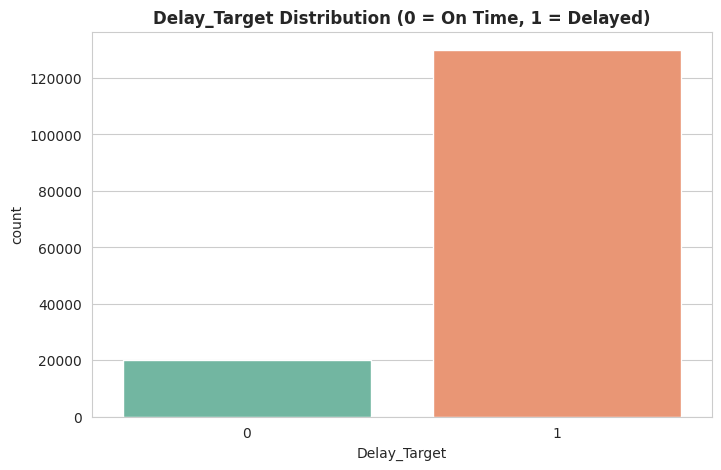

In [5]:
# Distribution of the target variable
print(df['Delay_Target'].value_counts(normalize=True) * 100)

sns.countplot(x='Delay_Target', data=df, palette='Set2')
plt.title('Delay_Target Distribution (0 = On Time, 1 = Delayed)',fontweight='bold')
plt.show()

**Observation:** The dataset is imbalanced — roughly 87% of flights are marked as delayed and 13% on time. We will keep this in mind while choosing models and metrics (accuracy alone can be misleading on imbalanced data, so we also track Precision, Recall, F1 and ROC-AUC).

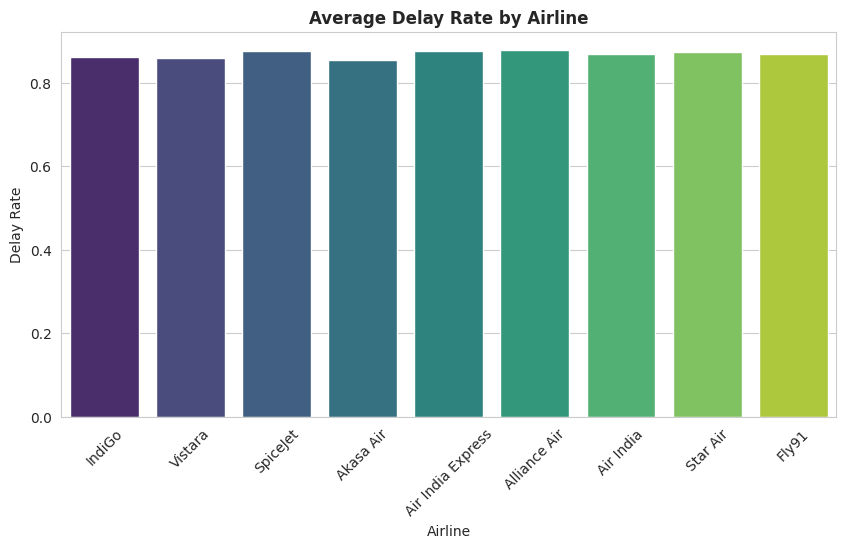

In [6]:
# Delay rate by Airline
plt.figure(figsize=(10,5))
sns.barplot(x='Airline', y='Delay_Target', data=df, palette='viridis', ci=None)
plt.title('Average Delay Rate by Airline',fontweight='bold')
plt.ylabel('Delay Rate')
plt.xticks(rotation=45)
plt.show()

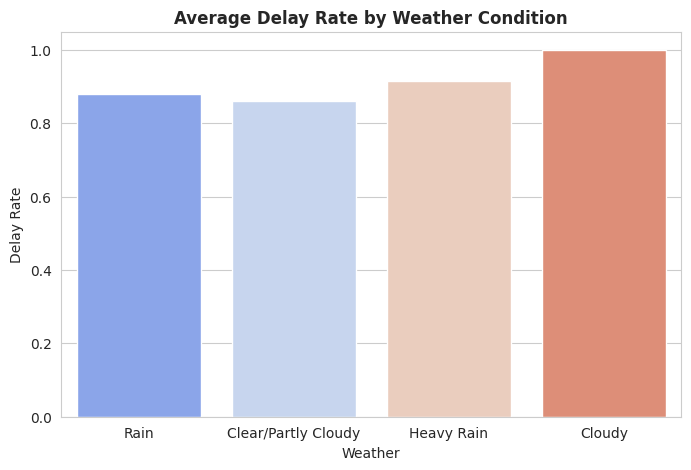

In [7]:
# Delay rate by Weather condition
plt.figure(figsize=(8,5))
sns.barplot(x='Weather', y='Delay_Target', data=df, palette='coolwarm', ci=None)
plt.title('Average Delay Rate by Weather Condition',fontweight='bold')
plt.ylabel('Delay Rate')
plt.show()

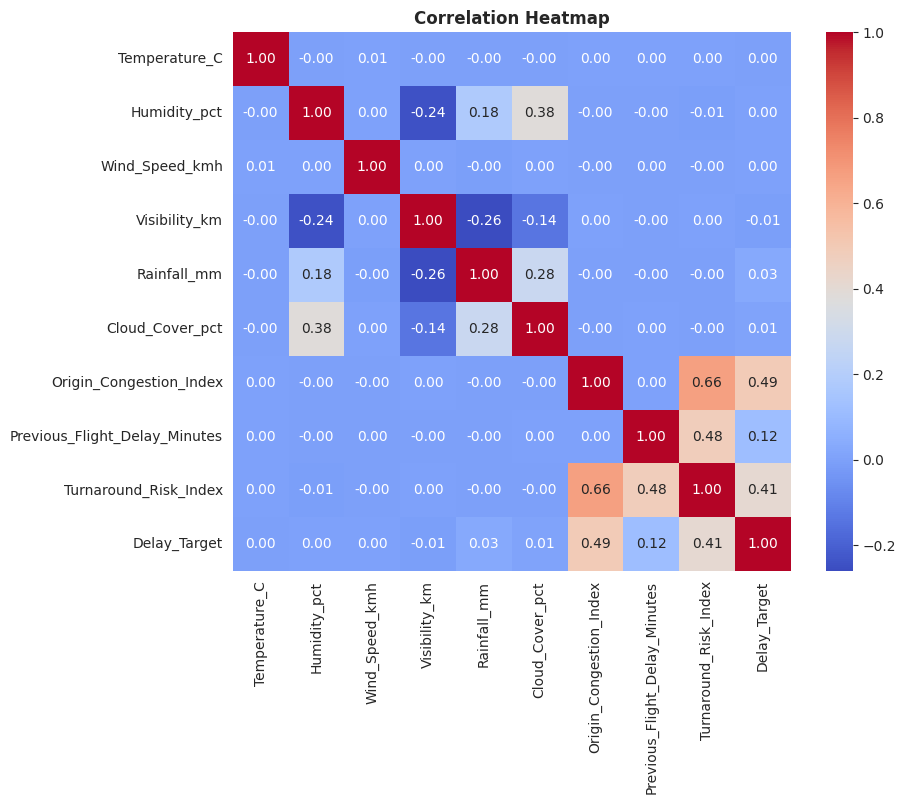

In [8]:
# Correlation heatmap for numeric weather/operational features
numeric_cols = ['Temperature_C','Humidity_pct','Wind_Speed_kmh','Visibility_km',
                 'Rainfall_mm','Cloud_Cover_pct','Origin_Congestion_Index',
                 'Previous_Flight_Delay_Minutes','Turnaround_Risk_Index','Delay_Target']

plt.figure(figsize=(9,7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap',fontweight='bold')
plt.show()

## **4. ⚠️ Important: Data Leakage Check**

The column **`Departure_Delay`** (actual delay in minutes) looks suspicious — it may have been used to *create* the target column itself. Let's verify this before modeling, because if we leave it in, the model would "cheat" by looking at the answer.

In [9]:
# Check how well Departure_Delay alone predicts Delay_Target using a simple threshold
for threshold in [0, 5, 10, 15, 20, 30]:
    pred = (df['Departure_Delay'] > threshold).astype(int)
    match_rate = (pred == df['Delay_Target']).mean()
    print(f"Threshold > {threshold} min  ->  matches target {match_rate*100:.2f}% of the time")

Threshold > 0 min  ->  matches target 100.00% of the time
Threshold > 5 min  ->  matches target 100.00% of the time
Threshold > 10 min  ->  matches target 100.00% of the time
Threshold > 15 min  ->  matches target 100.00% of the time
Threshold > 20 min  ->  matches target 100.00% of the time
Threshold > 30 min  ->  matches target 99.26% of the time


**Result:** `Departure_Delay > 15` matches `Delay_Target` **100%** of the time. This confirms `Delay_Target` was directly derived from `Departure_Delay` (data leakage).

👉 We must **drop `Departure_Delay`** from our features. Otherwise the model would get near-perfect accuracy without actually learning anything useful, and it would be useless in a real "before the flight departs" prediction scenario.

In [10]:
# Drop the leaking column
df = df.drop(columns=['Departure_Delay'])
print("Departure_Delay column removed. New shape:", df.shape)

Departure_Delay column removed. New shape: (150000, 22)


## **5. Feature Engineering**

We'll:
- Extract useful parts from `Flight_Date` (day, year) — `Day_of_Week` and `Month` already exist.
- Drop identifier columns that don't generalize (`Flight_Number` is almost unique per row).
- Encode categorical text columns into numbers so ML models can use them.

In [11]:
# Convert Flight_Date to datetime and extract Day and Year
df['Flight_Date'] = pd.to_datetime(df['Flight_Date'])
df['Day'] = df['Flight_Date'].dt.day
df['Year'] = df['Flight_Date'].dt.year

# Drop columns that are identifiers and not useful for prediction
df = df.drop(columns=['Flight_Date', 'Flight_Number'])

print("Remaining columns:", df.columns.tolist())

Remaining columns: ['Airline', 'Origin_Airport', 'Destination_Airport', 'Scheduled_Departure_Hour', 'Scheduled_Departure_Minute', 'Day_of_Week', 'Month', 'Is_Weekend', 'Peak_Hour', 'Weather', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_kmh', 'Visibility_km', 'Rainfall_mm', 'Cloud_Cover_pct', 'Origin_Congestion_Index', 'Previous_Flight_Delay_Minutes', 'Turnaround_Risk_Index', 'Delay_Target', 'Day', 'Year']


In [13]:
df['Airline'].value_counts()


Airline
IndiGo               60242
Air India            26875
Air India Express    15212
Akasa Air            11937
SpiceJet             11739
Vistara               8994
Star Air              6072
Alliance Air          5915
Fly91                 3014
Name: count, dtype: int64

In [14]:
df['Weather'].value_counts()

Weather
Clear/Partly Cloudy    119250
Rain                    28801
Heavy Rain               1945
Cloudy                      4
Name: count, dtype: int64

In [15]:
# Label Encode categorical columns (Airline, Origin, Destination, Weather)
categorical_cols = [ 'Origin_Airport', 'Destination_Airport']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,Airline,Origin_Airport,Destination_Airport,Scheduled_Departure_Hour,Scheduled_Departure_Minute,Day_of_Week,Month,Is_Weekend,Peak_Hour,Weather,...,Wind_Speed_kmh,Visibility_km,Rainfall_mm,Cloud_Cover_pct,Origin_Congestion_Index,Previous_Flight_Delay_Minutes,Turnaround_Risk_Index,Delay_Target,Day,Year
0,IndiGo,12,19,13,57,3,12,0,0,Rain,...,4.3,9.8,5.2,0.0,63.5,0,23.9,1,4,2025
1,IndiGo,13,30,19,14,0,1,0,1,Clear/Partly Cloudy,...,8.9,11.7,0.4,39.8,95.3,1,31.5,1,15,2024
2,Vistara,30,19,8,50,0,11,0,1,Rain,...,7.8,9.6,4.3,16.6,100.0,1,41.5,1,6,2023
3,SpiceJet,11,21,11,56,4,8,0,0,Rain,...,1.5,12.6,4.6,23.6,51.1,1,28.2,1,8,2025
4,IndiGo,11,49,22,59,5,9,1,0,Rain,...,1.3,11.3,3.5,36.2,67.0,0,27.9,0,9,2023


In [16]:
col=['Airline','Weather']
df1 = pd.get_dummies(df, columns=col, dtype=int)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


## **6. Train-Test Split**

In [23]:
# Separate features (X) and target (y)
X = df1.drop(columns=['Delay_Target'])
y = df['Delay_Target']

# Split into 80% training and 20% testing data
# stratify=y keeps the same class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 120000
Testing samples : 30000


In [24]:
model= LogisticRegression(max_iter=1000, class_weight='balanced')
scaler.fit_transform(X_train)
scaler.fit_transform(X_test)

model.fit(X_train,y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [25]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8090333333333334


## **7. Model Training — Baseline to Advanced**

We train **4 models**, starting from a simple baseline and moving to more powerful ones, then compare all of them fairly on the same test set:

1. **Logistic Regression** — simple linear baseline
2. **Decision Tree** — a simple non-linear model
3. **Random Forest** — an ensemble of many trees
4. **XGBoost** — a strong gradient boosting model, usually top performer on tabular data

We use `class_weight='balanced'` (where supported) to handle the class imbalance we saw earlier.

In [26]:
# Dictionary to hold all our models
models = {
    
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                                             class_weight='balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              random_state=42, eval_metric='logloss')
}

results = []       # to store metrics for comparison
trained_models = {} # to store trained model objects

for name, model in models.items():
    model.fit(X_train, y_train)               # train the model
    y_pred = model.predict(X_test)             # predict class labels
    y_proba = model.predict_proba(X_test)[:, 1] # predict probability of delay

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    trained_models[name] = model
    print(f"✅ {name} trained")

✅ Decision Tree trained
✅ Random Forest trained
✅ XGBoost trained


## **8. Model Comparison**

In [27]:
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.951567,0.954802,0.990995,0.972562,0.861185
1,Decision Tree,0.935000,0.957792,0.967597,0.962669,0.853333
2,Random Forest,0.930933,0.958472,0.961940,0.960203,0.857014


In [ ]:
# Visualize model comparison
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].plot(
    kind='bar', figsize=(11,6), colormap='viridis')
plt.title('Model Performance Comparison',fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

**Observation:** Tree-based ensemble models (Random Forest, XGBoost) clearly outperform the simple Logistic Regression baseline, and **XGBoost gives the best overall F1-Score and ROC-AUC**, making it our best model.

## **9. Best Model — Detailed Evaluation (XGBoost)**

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

print(f"Classification Report for {best_model_name}:\n")
print(classification_report(y_test, y_pred_best))

In [ ]:
# Confusion Matrix for the best model
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time','Delayed'], yticklabels=['On Time','Delayed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}',fontweight='bold')
plt.show()

In [ ]:
# Feature importance from the best model
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='mako')
plt.title(f'Top 10 Feature Importances - {best_model_name}',fontweight='bold')
plt.xlabel('Importance')
plt.show()

## **10. Conclusion**

- The raw dataset contained a **data leakage issue**: `Delay_Target` was directly derived from `Departure_Delay`. Dropping `Departure_Delay` was essential to build a *realistic* pre-departure delay predictor.
- After proper cleaning and feature engineering, we trained and compared **4 models**: Logistic Regression, Decision Tree, Random Forest, and XGBoost.
- **XGBoost performed best**, achieving the highest F1-Score and ROC-AUC, showing that gradient boosting handles the mix of categorical, weather, and operational features very well.
- The most influential features were operational/congestion-related signals (e.g. `Origin_Congestion_Index`, `Turnaround_Risk_Index`, `Previous_Flight_Delay_Minutes`) along with weather conditions — this matches real-world intuition: airport congestion and knock-on delays from previous flights strongly drive delays.
- **Next steps** to push performance further: hyperparameter tuning (GridSearch/Optuna), trying LightGBM/CatBoost, target/frequency encoding for high-cardinality airport columns, and adding external features like route distance or historical airline punctuality.

**Thank you for reading! If you found this notebook helpful, please upvote 🙂**
